# **Decision Stump**

# **Descripción**
Un Decision Stump es un árbol de decisión de profundidad máxima igual a 1, es decir, un árbol con un único nodo raíz que realiza exactamente una sola división sobre una variable predictora. Es el clasificador/regresor más simple dentro de la familia de árboles de decisión. Aunque su capacidad predictiva individual es limitada (aprendiz débil), su utilidad real radica en ser el componente base de algoritmos de ensemble como AdaBoost, Gradient Boosting y Random Forest simplificado. Su baja varianza y alto sesgo lo hacen ideal como weak learner en métodos de boosting.

# **Bibtex y Referencias:**
Freund, Y., & Schapire, R. E. (1997). A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting. Journal of Computer and System Sciences, 55(1), 119–139.



\@article{freund1997decision,
  author  = {Freund, Yoav and Schapire, Robert E.},
  title   = {A Decision-Theoretic Generalization of On-Line Learning
             and an Application to Boosting},
  journal = {Journal of Computer and System Sciences},
  year    = {1997},
  volume  = {55},
  number  = {1},
  pages   = {119--139},
  doi     = {10.1006/jcss.1997.1504}
}

@book{hastie2009elements,
  author    = {Hastie, Trevor and Tibshirani, Robert
               and Friedman, Jerome},
  title     = {The Elements of Statistical Learning},
  edition   = {2},
  publisher = {Springer},
  year      = {2009},
  note      = {Cap. 10: Boosting and Additive Trees}
}

# **Tipo de Modelo**

**Método de aprendizaje**

* Aprendizaje Supervisado
* Clasificación
* Regresión

**Por parámetros**
* No Paramétrico

**Datos de aprendizaje**
* Aprendizaje Offline (Batch)

**Resultado del entrenamiento**
* Árbol de decisión (profundidad = 1)
* Aprendiz Débil (Weak Learner)
* Modelo Simbólico / Interpretable


**Algoritmo de Entrenamiento**
* Búsqueda exhaustiva del mejor corte
* Minimización de impureza (Gini / Entropía)
* Minimización de MSE (regresión)

El proceso: (1) Para cada variable predictora, evalúa todos los posibles umbrales de corte. (2) Selecciona la variable y umbral que minimiza la impureza ponderada de los dos nodos hijos. (3) Produce exactamente dos hojas. (4) En boosting, los pesos de las instancias mal clasificadas son actualizados antes de entrenar el siguiente stump.




# **Supuestos y Restricciones**
* Profundidad fija igual a 1: solo puede representar fronteras de decisión paralelas a los ejes (una sola condición if-else).
* Alto sesgo (underfitting): por sí solo no puede capturar relaciones complejas ni interacciones entre variables.
* No asume distribución específica de los datos ni linealidad.
* Sensible a variables irrelevantes: si la mejor variable es ruidosa, el stump será un predictor muy pobre.
* En clasificación binaria, su rendimiento mínimo esperado es 50% (equivalente al azar); se requiere que supere el azar para ser útil en boosting.
* En contexto de AdaBoost: se asume que los datos tienen pesos asociados que se actualizan en cada iteración.
* No requiere normalización de características.

# 🪵 Decision Stump
### Árbol de decisión de profundidad 1 — el aprendiz débil perfecto

---
**¿Qué es un Decision Stump?**

Es el árbol más simple posible: **una sola condición if-else**.
- Solo puede hacer **una** pregunta sobre **una** variable.
- Produce exactamente **dos** nodos hoja.
- Por sí solo predice mal (alto sesgo), pero combinado en **ensemble → poderoso**.

**Estructura:**
```
        [¿Xⱼ ≤ θ?]
         /        \
    SÍ ↙          ↘ NO
  Clase A        Clase B
```
**Uso real:** Es el `base_estimator` predeterminado de **AdaBoost**.

---

## Celda 1 — Instalación de dependencias

In [13]:
!pip install matplotlib seaborn numpy pandas scikit-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.tree import (
    DecisionTreeClassifier, DecisionTreeRegressor,
    plot_tree, export_text
)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_classification, make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42
print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


## Celda 2 — ¿Qué hace exactamente un Decision Stump?

Visualizamos cómo el stump busca el **mejor corte posible** en una sola variable.

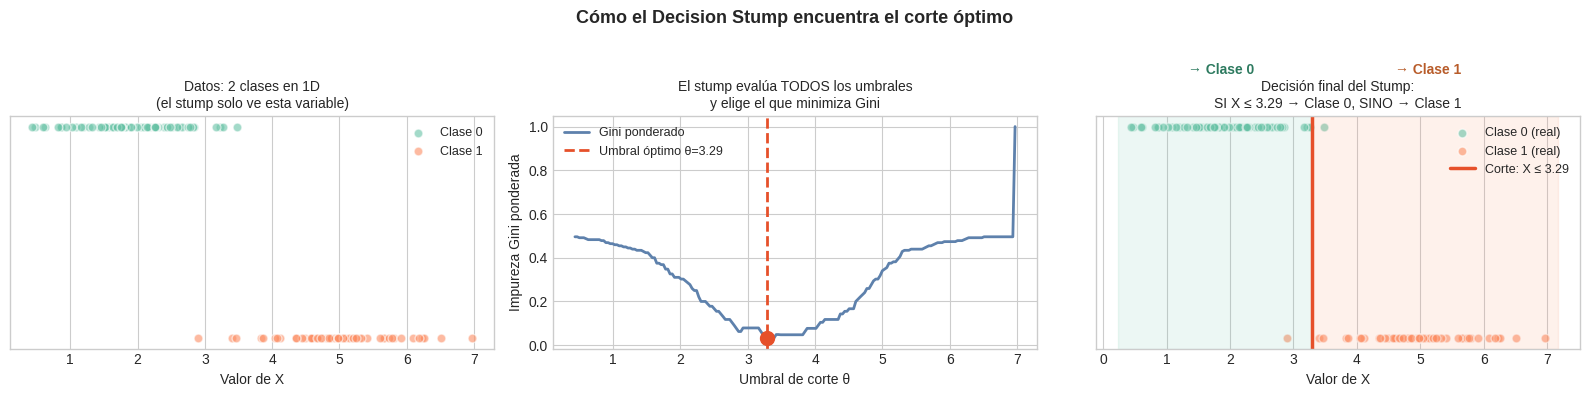

In [22]:
# ─── Simulación: búsqueda del umbral óptimo ────────────────────────────────────
# Generamos datos 1D con dos clases claramente separables
np.random.seed(RANDOM_STATE)
n = 60
x_cls0 = np.random.normal(loc=2.0, scale=0.8, size=n)
x_cls1 = np.random.normal(loc=5.0, scale=0.8, size=n)
X_1d   = np.concatenate([x_cls0, x_cls1]).reshape(-1, 1)
y_1d   = np.concatenate([np.zeros(n), np.ones(n)]).astype(int)

# Calcular impureza Gini para cada umbral posible
umbrales = np.linspace(X_1d.min(), X_1d.max(), 200)
ginis = []
for theta in umbrales:
    izq  = y_1d[X_1d.ravel() <= theta]
    der  = y_1d[X_1d.ravel() >  theta]
    n_i, n_d = len(izq), len(der)
    if n_i == 0 or n_d == 0:
        ginis.append(1.0)
        continue
    def gini(arr):
        if len(arr) == 0: return 0
        p = np.mean(arr)
        return 1 - p**2 - (1-p)**2
    gini_pond = (n_i * gini(izq) + n_d * gini(der)) / (n_i + n_d)
    ginis.append(gini_pond)

ginis = np.array(ginis)
theta_optimo = umbrales[np.argmin(ginis)]

# ─── Plot: búsqueda del umbral ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Cómo el Decision Stump encuentra el corte óptimo',
             fontsize=13, fontweight='bold')

# Plot 1: datos raw
ax = axes[0]
ax.scatter(x_cls0, np.zeros(len(x_cls0)) + 0.1, c='#66C2A5', alpha=0.6,
           edgecolors='white', s=40, label='Clase 0')
ax.scatter(x_cls1, np.zeros(len(x_cls1)) - 0.1, c='#FC8D62', alpha=0.6,
           edgecolors='white', s=40, label='Clase 1')
ax.set_yticks([])
ax.set_xlabel('Valor de X')
ax.set_title('Datos: 2 clases en 1D\n(el stump solo ve esta variable)', fontsize=10)
ax.legend(fontsize=9)

# Plot 2: curva de impureza Gini
ax = axes[1]
ax.plot(umbrales, ginis, color='#5E81AC', linewidth=2, label='Gini ponderado')
ax.axvline(x=theta_optimo, color='#E6502A', linewidth=2,
           linestyle='--', label=f'Umbral óptimo θ={theta_optimo:.2f}')
ax.scatter([theta_optimo], [min(ginis)], color='#E6502A', s=100, zorder=5)
ax.set_xlabel('Umbral de corte θ')
ax.set_ylabel('Impureza Gini ponderada')
ax.set_title('El stump evalúa TODOS los umbrales\ny elige el que minimiza Gini', fontsize=10)
ax.legend(fontsize=9)

# Plot 3: decisión final
ax = axes[2]
ax.scatter(x_cls0, np.zeros(len(x_cls0)) + 0.1, c='#66C2A5', alpha=0.6,
           edgecolors='white', s=40, label='Clase 0 (real)')
ax.scatter(x_cls1, np.zeros(len(x_cls1)) - 0.1, c='#FC8D62', alpha=0.6,
           edgecolors='white', s=40, label='Clase 1 (real)')
ax.axvline(x=theta_optimo, color='#E6502A', linewidth=2.5,
           linestyle='-', label=f'Corte: X ≤ {theta_optimo:.2f}')
ax.axvspan(min(x_cls0.min(), x_cls1.min())-0.2, theta_optimo, alpha=0.12, color='#66C2A5')
ax.axvspan(theta_optimo, max(x_cls0.max(), x_cls1.max())+0.2, alpha=0.12, color='#FC8D62')
ax.text((x_cls0.min() + theta_optimo)/2, 0.15, '→ Clase 0',
        ha='center', fontsize=10, color='#2d7a5f', fontweight='bold')
ax.text((theta_optimo + x_cls1.max())/2, 0.15, '→ Clase 1',
        ha='center', fontsize=10, color='#b85c2a', fontweight='bold')
ax.set_yticks([])
ax.set_xlabel('Valor de X')
ax.set_title(f'Decisión final del Stump:\nSI X ≤ {theta_optimo:.2f} → Clase 0, SINO → Clase 1', fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('stump_umbral.png', dpi=130, bbox_inches='tight')
plt.show()


## Celda 3 — Datos: Dataset Make Moons + Cancer

Usamos dos datasets para mostrar las fortalezas y limitaciones del stump.

/tmp/ipykernel_19954/1014151098.py:45: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_19954/1014151098.py:45: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_19954/1014151098.py:46: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('stump_datos.png', dpi=130, bbox_inches='tight')
/tmp/ipykernel_19954/1014151098.py:46: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.savefig('stump_datos.png', dpi=130, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans

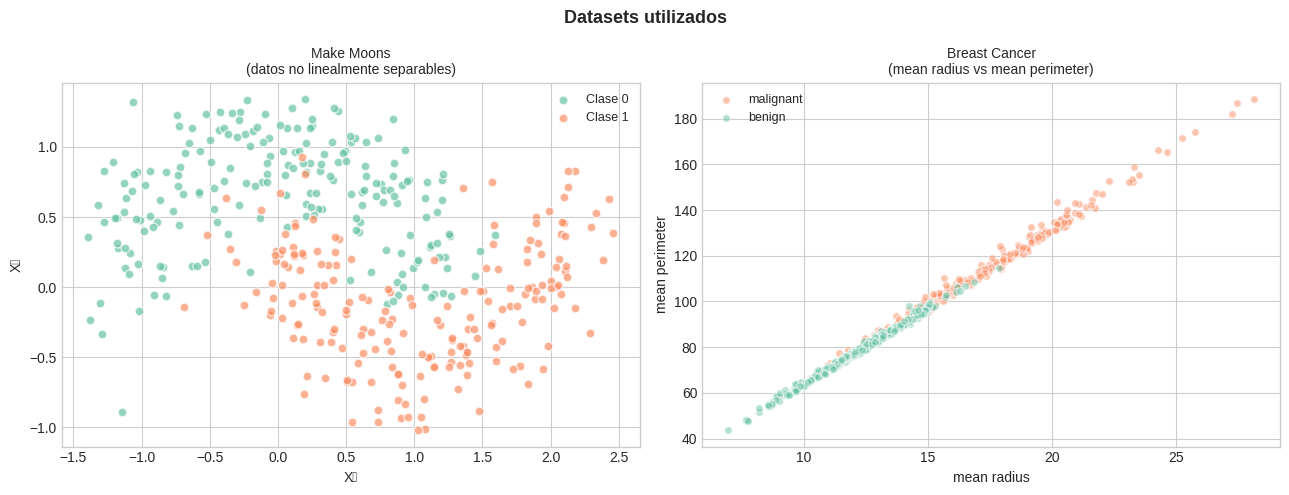

Moons  : 400 instancias, 2 variables
Cancer : 569 instancias, 30 variables


In [15]:
# ─── Dataset 1: Make Moons (no linealmente separable) ─────────────────────────
X_moons, y_moons = make_moons(n_samples=400, noise=0.25, random_state=RANDOM_STATE)

# ─── Dataset 2: Breast Cancer (binario, 30 variables) ─────────────────────────
cancer = load_breast_cancer()
X_bc   = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_bc   = pd.Series(cancer.target)

# División
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=RANDOM_STATE
)
X_tr_bc, X_te_bc, y_tr_bc, y_te_bc = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=RANDOM_STATE, stratify=y_bc
)

# ─── Visualización de los datos ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Datasets utilizados', fontsize=13, fontweight='bold')

# Moons
ax = axes[0]
for cls, col, lbl in zip([0, 1], ['#66C2A5', '#FC8D62'], ['Clase 0', 'Clase 1']):
    mask = y_moons == cls
    ax.scatter(X_moons[mask, 0], X_moons[mask, 1],
               c=col, alpha=0.7, edgecolors='white', s=40, label=lbl)
ax.set_title('Make Moons\n(datos no linealmente separables)', fontsize=10)
ax.legend(fontsize=9)
ax.set_xlabel('X₁'); ax.set_ylabel('X₂')

# Cancer: distribución de primeras 2 variables
ax = axes[1]
nombres_bc = ['malignant', 'benign']
colores_bc = ['#FC8D62', '#66C2A5']
for cls, col, lbl in zip([0, 1], colores_bc, nombres_bc):
    mask = y_bc == cls
    ax.scatter(X_bc.loc[mask, X_bc.columns[0]],
           X_bc.loc[mask, X_bc.columns[2]],
           c=col, alpha=0.5, edgecolors='white', s=30, label=lbl)
ax.set_title('Breast Cancer\n(mean radius vs mean perimeter)', fontsize=10)
ax.set_xlabel(cancer.feature_names[0])
ax.set_ylabel(cancer.feature_names[2])
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('stump_datos.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Moons  : {X_moons.shape[0]} instancias, 2 variables')
print(f'Cancer : {X_bc.shape[0]} instancias, {X_bc.shape[1]} variables')

## Celda 4 — Entrenamiento del Stump y visualización de frontera

🌳 Decision Stump entrenado (Make Moons):
|--- X₂ <= 0.27
|   |--- class: 1
|--- X₂ >  0.27
|   |--- class: 0

   Accuracy en test: 0.7917 (79.2%)


/usr/local/lib/python3.12/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  ann.update_bbox_position_size(renderer)
/tmp/ipykernel_19954/3774079682.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.get_cmap('Set2', 2))
/tmp/ipykernel_19954/3774079682.py:55: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_19954/3774079682.py:55: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_19954/3774079682.py:56: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('stump_estructura_frontera.png', dpi=130, bbox_inches='ti

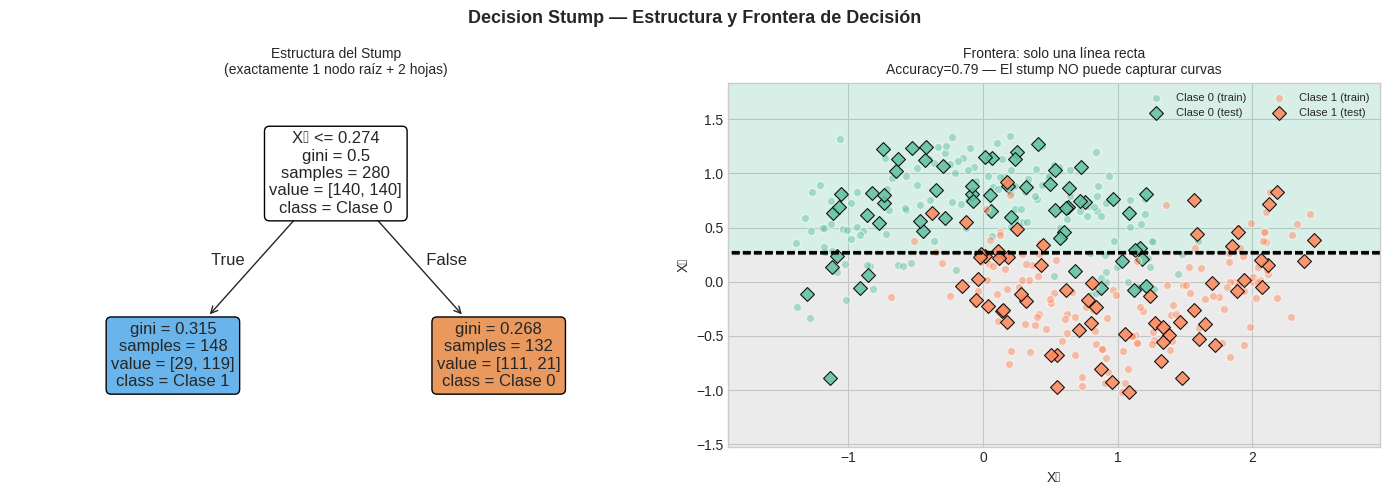


💡 CLAVE: El stump solo produce fronteras paralelas a los ejes.
   Esto lo hace un APRENDIZ DÉBIL — perfecto para boosting.


In [16]:
# ─── Entrenar stump básico ─────────────────────────────────────────────────────
stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
stump.fit(X_tr_m, y_tr_m)

acc_stump = accuracy_score(y_te_m, stump.predict(X_te_m))

print('🌳 Decision Stump entrenado (Make Moons):')
print(export_text(stump, feature_names=['X₁', 'X₂']))
print(f'   Accuracy en test: {acc_stump:.4f} ({acc_stump*100:.1f}%)')

# ─── Plot: árbol + frontera de decisión ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision Stump — Estructura y Frontera de Decisión',
             fontsize=13, fontweight='bold')

# Árbol
ax = axes[0]
plot_tree(
    stump,
    feature_names=['X₁', 'X₂'],
    class_names=['Clase 0', 'Clase 1'],
    filled=True, rounded=True, fontsize=12, ax=ax, impurity=True
)
ax.set_title('Estructura del Stump\n(exactamente 1 nodo raíz + 2 hojas)', fontsize=10)

# Frontera de decisión
ax = axes[1]
h = 0.02
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = stump.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.get_cmap('Set2', 2))
ax.contour(xx, yy, Z, colors='black', linewidths=1.5, linestyles='--', alpha=0.6)

for cls, col, lbl in zip([0, 1], ['#66C2A5', '#FC8D62'], ['Clase 0', 'Clase 1']):
    mask_tr = y_tr_m == cls
    mask_te = y_te_m == cls
    ax.scatter(X_tr_m[mask_tr, 0], X_tr_m[mask_tr, 1],
               c=col, alpha=0.5, edgecolors='white', s=35, label=f'{lbl} (train)')
    ax.scatter(X_te_m[mask_te, 0], X_te_m[mask_te, 1],
               c=col, alpha=0.9, edgecolors='black', linewidths=0.8, s=50,
               marker='D', label=f'{lbl} (test)')

ax.set_title(
    f'Frontera: solo una línea recta\n'
    f'Accuracy={acc_stump:.2f} — El stump NO puede capturar curvas',
    fontsize=10
)
ax.set_xlabel('X₁'); ax.set_ylabel('X₂')
ax.legend(fontsize=8, ncol=2, loc='upper right')

plt.tight_layout()
plt.savefig('stump_estructura_frontera.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n💡 CLAVE: El stump solo produce fronteras paralelas a los ejes.')
print('   Esto lo hace un APRENDIZ DÉBIL — perfecto para boosting.')

## Celda 5 — Paso a paso: cómo AdaBoost combina stumps

Visualizamos cómo cada stump aprende de los errores del anterior.

/tmp/ipykernel_19954/47532159.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax_bot.contourf(xx, yy, Z_ens, alpha=0.25, cmap=plt.cm.get_cmap('Set2', 2))
/tmp/ipykernel_19954/47532159.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax_bot.contourf(xx, yy, Z_ens, alpha=0.25, cmap=plt.cm.get_cmap('Set2', 2))
/tmp/ipykernel_19954/47532159.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax_bot.contourf(xx, yy, Z_ens, alpha=0.25, cmap=plt.cm.get_cmap('

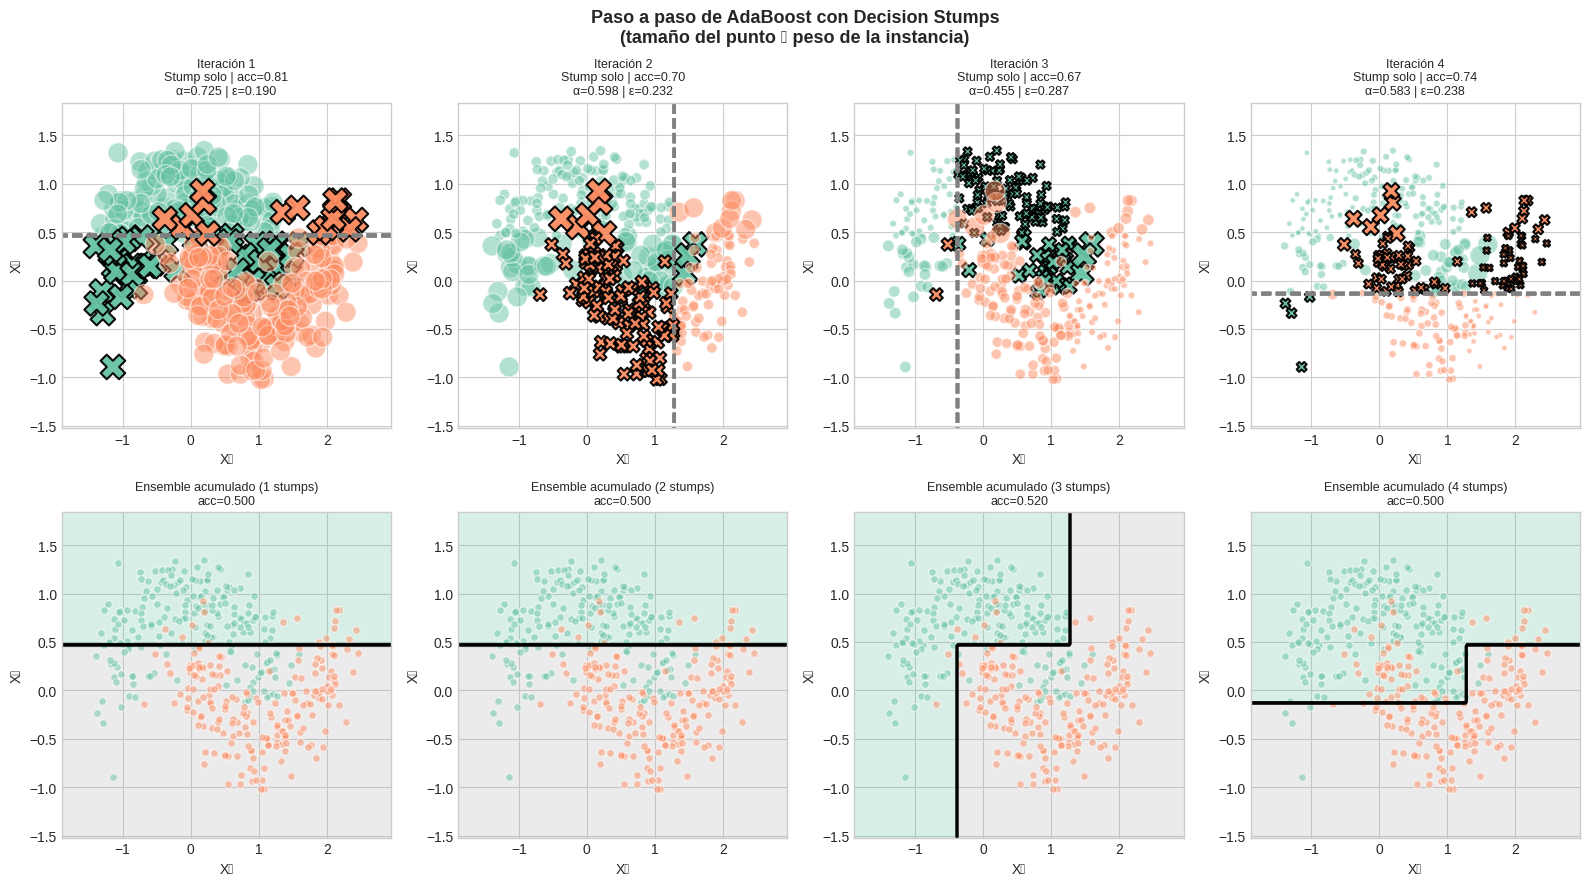


💡 Observa:
   Fila superior (✕): instancias mal clasificadas → más peso en siguiente iteración
   Fila inferior   : la frontera del ensemble se vuelve más compleja con cada stump


In [17]:
# ─── Simulación manual de AdaBoost con stumps ─────────────────────────────────
# Mostramos las primeras 4 iteraciones de forma didáctica

np.random.seed(RANDOM_STATE)
X_ada = X_moons.copy()
y_ada = y_moons.copy()
n_total = len(y_ada)

# Pesos iniciales: todos iguales
pesos   = np.ones(n_total) / n_total
stumps  = []
alphas  = []

N_ITER = 4
fig, axes = plt.subplots(2, N_ITER, figsize=(16, 9))
fig.suptitle(
    'Paso a paso de AdaBoost con Decision Stumps\n'
    '(tamaño del punto ∝ peso de la instancia)',
    fontsize=13, fontweight='bold'
)

for t in range(N_ITER):
    # Entrenar stump con pesos actuales
    stump_t = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE + t)
    stump_t.fit(X_ada, y_ada, sample_weight=pesos)
    pred_t = stump_t.predict(X_ada)

    # Error ponderado
    errores   = (pred_t != y_ada).astype(float)
    eps_t     = np.dot(pesos, errores) / pesos.sum()
    eps_t     = np.clip(eps_t, 1e-10, 1 - 1e-10)  # Evitar log(0)

    # Peso del clasificador
    alpha_t   = 0.5 * np.log((1 - eps_t) / eps_t)
    alphas.append(alpha_t)
    stumps.append(stump_t)

    # ─── Fila 1: tamaño de punto según peso ───────────────────────────────────
    ax_top = axes[0][t]
    tamaños = (pesos / pesos.max()) * 200 + 10
    for cls, col in zip([0, 1], ['#66C2A5', '#FC8D62']):
        mask = y_ada == cls
        # Bien clasificados
        bien = mask & (pred_t == y_ada)
        mal  = mask & (pred_t != y_ada)
        ax_top.scatter(X_ada[bien, 0], X_ada[bien, 1],
                       c=col, s=tamaños[bien], alpha=0.5, edgecolors='white')
        ax_top.scatter(X_ada[mal, 0], X_ada[mal, 1],
                       c=col, s=tamaños[mal]*1.5, alpha=0.95,
                       edgecolors='black', linewidths=1.5, marker='X')

    # Frontera del stump actual
    Z_t = stump_t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax_top.contour(xx, yy, Z_t, colors='gray', linewidths=2, linestyles='--', alpha=0.8)
    acc_t = accuracy_score(y_ada, pred_t)
    ax_top.set_title(f'Iteración {t+1}\nStump solo | acc={acc_t:.2f}\nα={alpha_t:.3f} | ε={eps_t:.3f}',
                     fontsize=9)
    ax_top.set_xlabel('X₁'); ax_top.set_ylabel('X₂')

    # ─── Fila 2: frontera acumulada del ensemble hasta t ──────────────────────
    ax_bot = axes[1][t]
    votos = np.zeros(len(xx.ravel()))
    for s, a in zip(stumps, alphas):
        pred_s = s.predict(np.c_[xx.ravel(), yy.ravel()])
        votos += a * (2 * pred_s - 1)  # Convertir 0/1 a -1/+1
    Z_ens = (votos > 0).astype(int).reshape(xx.shape)
    ax_bot.contourf(xx, yy, Z_ens, alpha=0.25, cmap=plt.cm.get_cmap('Set2', 2))
    ax_bot.contour(xx, yy, Z_ens, colors='black', linewidths=1.5, alpha=0.7)
    for cls, col in zip([0, 1], ['#66C2A5', '#FC8D62']):
        mask = y_ada == cls
        ax_bot.scatter(X_ada[mask, 0], X_ada[mask, 1],
                       c=col, s=30, alpha=0.5, edgecolors='white')
    # Predicciones del ensemble sobre el conjunto real
    preds_ens = (votos[:len(y_ada)] > 0).astype(int)   # recorta a 400
    acc_ens = accuracy_score(y_ada, preds_ens)

    ax_bot.set_title(f'Ensemble acumulado ({t+1} stumps)\nacc={acc_ens:.3f}', fontsize=9)
    ax_bot.set_xlabel('X₁'); ax_bot.set_ylabel('X₂')

    # Actualizar pesos (más peso a los errores)
    pesos = pesos * np.exp(alpha_t * errores * 2)
    pesos = pesos / pesos.sum()  # Normalizar

plt.tight_layout()
plt.savefig('stump_adaboost_pasos.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n💡 Observa:')
print('   Fila superior (✕): instancias mal clasificadas → más peso en siguiente iteración')
print('   Fila inferior   : la frontera del ensemble se vuelve más compleja con cada stump')

## Celda 6 — AdaBoost completo: efecto del número de stumps

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

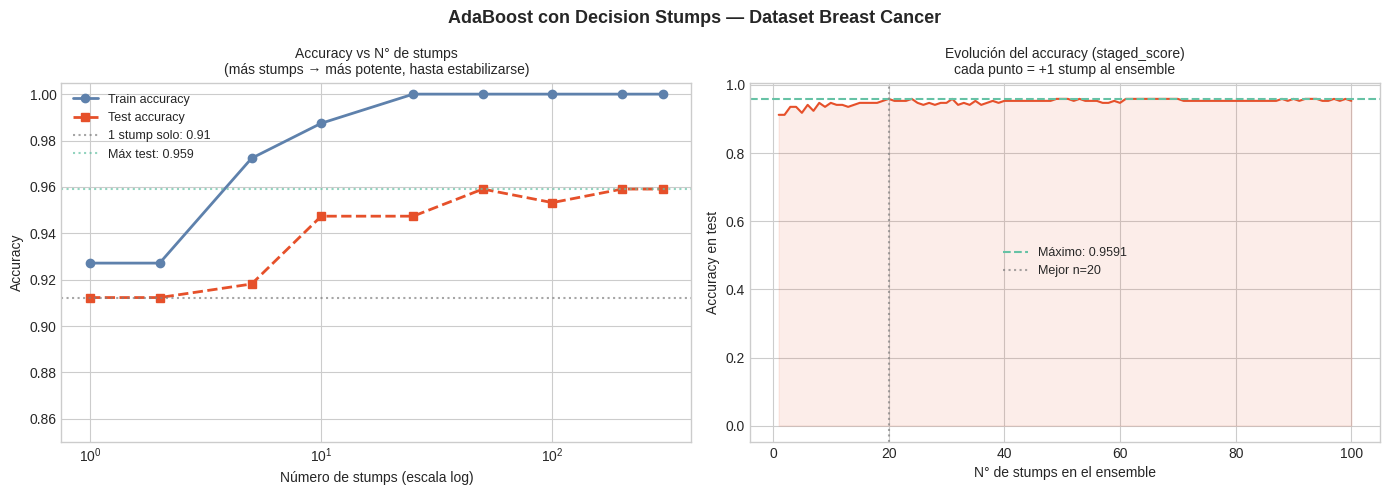


📈 1 stump solo  : 0.9123
   100 stumps    : 0.9591
   Mejora total  : +4.7 pp


In [18]:
# ─── Accuracy vs número de stumps (Breast Cancer) ──────────────────────────────
n_stumps_lista = [1, 2, 5, 10, 25, 50, 100, 200, 300]
acc_train_lista = []
acc_test_lista  = []

for n_s in n_stumps_lista:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n_s,
        learning_rate=1.0,
        algorithm='SAMME',
        random_state=RANDOM_STATE
    )
    ada.fit(X_tr_bc, y_tr_bc)
    acc_train_lista.append(accuracy_score(y_tr_bc, ada.predict(X_tr_bc)))
    acc_test_lista.append(accuracy_score(y_te_bc,  ada.predict(X_te_bc)))

# ─── Plot: curvas de aprendizaje ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AdaBoost con Decision Stumps — Dataset Breast Cancer',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(n_stumps_lista, acc_train_lista, 'o-', color='#5E81AC',
        linewidth=2, markersize=6, label='Train accuracy')
ax.plot(n_stumps_lista, acc_test_lista, 's--', color='#E6502A',
        linewidth=2, markersize=6, label='Test accuracy')
ax.axhline(y=acc_test_lista[0], color='gray', linestyle=':', alpha=0.7,
           label=f'1 stump solo: {acc_test_lista[0]:.2f}')
ax.axhline(y=max(acc_test_lista), color='#66C2A5', linestyle=':', alpha=0.7,
           label=f'Máx test: {max(acc_test_lista):.3f}')
ax.set_xscale('log')
ax.set_xlabel('Número de stumps (escala log)', fontsize=10)
ax.set_ylabel('Accuracy', fontsize=10)
ax.set_title('Accuracy vs N° de stumps\n(más stumps → más potente, hasta estabilizarse)', fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0.85, 1.005)

# Modelo final
ada_final = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    algorithm='SAMME',
    random_state=RANDOM_STATE
)
ada_final.fit(X_tr_bc, y_tr_bc)

# Evolución del error dentro del fit
ax = axes[1]
errores_staged = list(ada_final.staged_score(X_te_bc, y_te_bc))
ax.plot(range(1, 101), errores_staged, color='#E6502A', linewidth=1.5)
ax.fill_between(range(1, 101), errores_staged, alpha=0.1, color='#E6502A')
ax.axhline(y=max(errores_staged), color='#66C2A5', linestyle='--',
           label=f'Máximo: {max(errores_staged):.4f}')
mejor_n = np.argmax(errores_staged) + 1
ax.axvline(x=mejor_n, color='gray', linestyle=':', alpha=0.7,
           label=f'Mejor n={mejor_n}')
ax.set_xlabel('N° de stumps en el ensemble', fontsize=10)
ax.set_ylabel('Accuracy en test', fontsize=10)
ax.set_title('Evolución del accuracy (staged_score)\ncada punto = +1 stump al ensemble', fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('stump_curvas_aprendizaje.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'\n📈 1 stump solo  : {acc_test_lista[0]:.4f}')
print(f'   100 stumps    : {acc_test_lista[-4]:.4f}')
print(f'   Mejora total  : +{(acc_test_lista[-4] - acc_test_lista[0])*100:.1f} pp')

## Celda 7 — Pesos del ensemble: ¿cuánto vale cada stump?

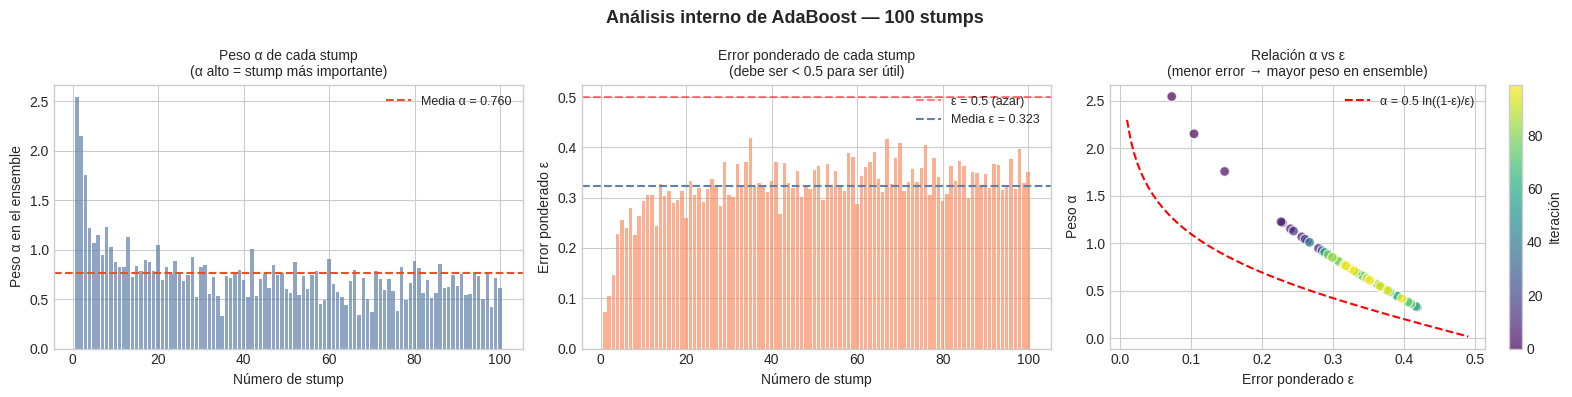


📊 Los primeros stumps suelen tener mayor peso (α).
   Conforme avanza el boosting, las instancias difíciles
   dominan el entrenamiento y los errores crecen.


In [19]:
# ─── Análisis de los pesos (alpha) y errores por stump ────────────────────────
pesos_stumps  = ada_final.estimator_weights_
errores_stumps = ada_final.estimator_errors_

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Análisis interno de AdaBoost — 100 stumps', fontsize=13, fontweight='bold')

# Plot 1: pesos alpha de cada stump
ax = axes[0]
ax.bar(range(1, 101), pesos_stumps, color='#5E81AC', alpha=0.7, width=0.8)
ax.set_xlabel('Número de stump')
ax.set_ylabel('Peso α en el ensemble')
ax.set_title('Peso α de cada stump\n(α alto = stump más importante)', fontsize=10)
ax.axhline(y=pesos_stumps.mean(), color='#E6502A', linestyle='--',
           label=f'Media α = {pesos_stumps.mean():.3f}')
ax.legend(fontsize=9)

# Plot 2: error ponderado por stump
ax = axes[1]
ax.bar(range(1, 101), errores_stumps, color='#FC8D62', alpha=0.7, width=0.8)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='ε = 0.5 (azar)')
ax.axhline(y=errores_stumps.mean(), color='#5E81AC', linestyle='--',
           label=f'Media ε = {errores_stumps.mean():.3f}')
ax.set_xlabel('Número de stump')
ax.set_ylabel('Error ponderado ε')
ax.set_title('Error ponderado de cada stump\n(debe ser < 0.5 para ser útil)', fontsize=10)
ax.legend(fontsize=9)

# Plot 3: relación alpha ~ error
ax = axes[2]
sc = ax.scatter(errores_stumps, pesos_stumps, c=range(100),
                cmap='viridis', alpha=0.7, s=50, edgecolors='white')
plt.colorbar(sc, ax=ax, label='Iteración')
eps_curva = np.linspace(0.01, 0.49, 100)
alpha_curva = 0.5 * np.log((1 - eps_curva) / eps_curva)
ax.plot(eps_curva, alpha_curva, 'r--', linewidth=1.5, label='α = 0.5 ln((1-ε)/ε)')
ax.set_xlabel('Error ponderado ε')
ax.set_ylabel('Peso α')
ax.set_title('Relación α vs ε\n(menor error → mayor peso en ensemble)', fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('stump_pesos_analisis.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'\n📊 Los primeros stumps suelen tener mayor peso (α).')
print(f'   Conforme avanza el boosting, las instancias difíciles')
print(f'   dominan el entrenamiento y los errores crecen.')

## Celda 8 — Evaluación final: Stump vs Árbol completo vs AdaBoost

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

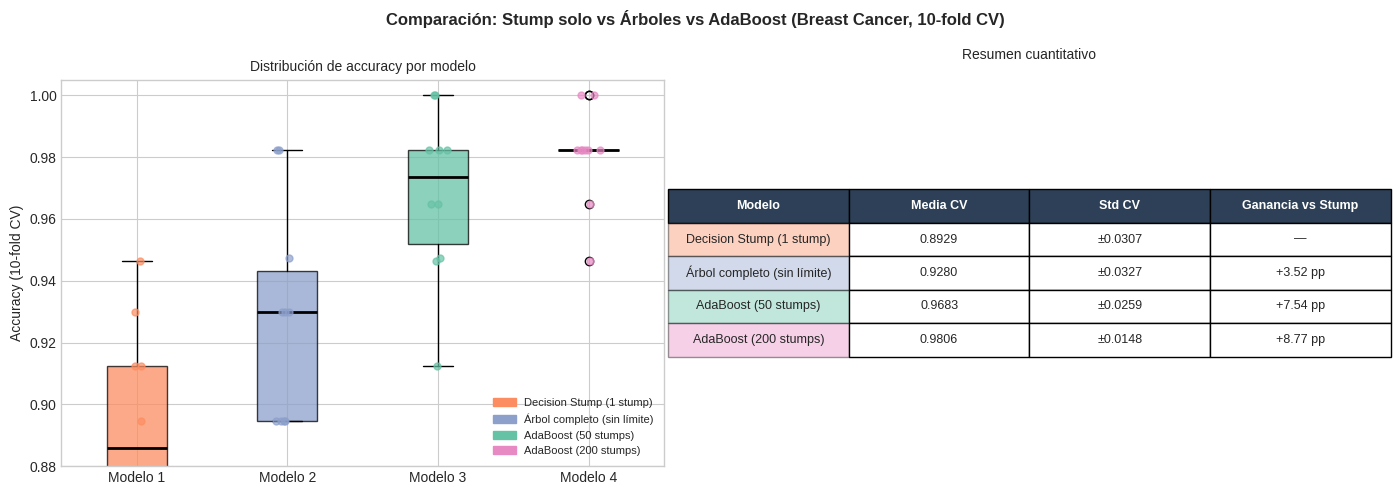


📈 LECCIÓN PRINCIPAL:
   Decision Stump (1 stump)           : 0.8929 ± 0.0307
   Árbol completo (sin límite)        : 0.9280 ± 0.0327
   AdaBoost (50 stumps)               : 0.9683 ± 0.0259
   AdaBoost (200 stumps)              : 0.9806 ± 0.0148


In [20]:
# ─── Comparación de modelos ────────────────────────────────────────────────────
modelos = {
    'Decision Stump\n(1 stump)':    DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    'Árbol completo\n(sin límite)': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'AdaBoost\n(50 stumps)':        AdaBoostClassifier(
                                        estimator=DecisionTreeClassifier(max_depth=1),
                                        n_estimators=50, algorithm='SAMME',
                                        random_state=RANDOM_STATE),
    'AdaBoost\n(200 stumps)':       AdaBoostClassifier(
                                        estimator=DecisionTreeClassifier(max_depth=1),
                                        n_estimators=200, algorithm='SAMME',
                                        random_state=RANDOM_STATE),
}

resultados = []
for nombre, modelo in modelos.items():
    cv_scores = cross_val_score(modelo, X_bc, y_bc, cv=10, scoring='accuracy')
    modelo.fit(X_tr_bc, y_tr_bc)
    resultados.append({
        'Modelo': nombre.replace('\n', ' '),
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'scores': cv_scores
    })

# ─── Plot: comparación ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación: Stump solo vs Árboles vs AdaBoost (Breast Cancer, 10-fold CV)',
             fontsize=12, fontweight='bold')

# Boxplots
ax = axes[0]
colores_mod = ['#FC8D62', '#8DA0CB', '#66C2A5', '#E78AC3']
etiquetas = [r['Modelo'] for r in resultados]
scores_todos = [r['scores'] for r in resultados]
bp = ax.boxplot(scores_todos, labels=[f'Modelo {i+1}' for i in range(4)],
                patch_artist=True, widths=0.4,
                medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp['boxes'], colores_mod):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
for i, (scores, col) in enumerate(zip(scores_todos, colores_mod)):
    ax.scatter(np.full(len(scores), i+1) + np.random.normal(0, 0.04, len(scores)),
               scores, color=col, alpha=0.7, zorder=3, s=25)
ax.set_ylabel('Accuracy (10-fold CV)')
ax.set_title('Distribución de accuracy por modelo', fontsize=10)
parches = [mpatches.Patch(color=c, label=e.replace('\n', ' '))
           for c, e in zip(colores_mod, etiquetas)]
ax.legend(handles=parches, fontsize=8, loc='lower right')
ax.set_ylim(0.88, 1.005)

# Tabla resumen
ax = axes[1]
ax.axis('off')
filas = [['Modelo', 'Media CV', 'Std CV', 'Ganancia vs Stump']]
base = resultados[0]['CV Mean']
for r, col in zip(resultados, colores_mod):
    ganancia = f"+{(r['CV Mean'] - base)*100:.2f} pp" if r != resultados[0] else "—"
    filas.append([r['Modelo'].replace('\n', ' '),
                  f"{r['CV Mean']:.4f}",
                  f"±{r['CV Std']:.4f}",
                  ganancia])
tabla = ax.table(cellText=filas[1:], colLabels=filas[0],
                 loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.2, 2.0)
for j in range(4):
    tabla[(0, j)].set_facecolor('#2E4057')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')
for i, col in enumerate(colores_mod, start=1):
    tabla[(i, 0)].set_facecolor(col)
    tabla[(i, 0)].set_alpha(0.4)
ax.set_title('Resumen cuantitativo', fontsize=10, pad=15)

plt.tight_layout()
plt.savefig('stump_comparacion.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n📈 LECCIÓN PRINCIPAL:')
for r in resultados:
    print(f"   {r['Modelo'].replace(chr(10), ' '):<35}: {r['CV Mean']:.4f} ± {r['CV Std']:.4f}")

## Celda 9 — Resumen visual y conclusiones

/tmp/ipykernel_19954/2928487354.py:44: UserWarning: Glyph 7522 (\N{LATIN SUBSCRIPT SMALL LETTER I}) missing from font(s) Liberation Sans.
  plt.savefig('stump_resumen_adaboost.png', dpi=130, bbox_inches='tight')
/tmp/ipykernel_19954/2928487354.py:44: UserWarning: Glyph 8348 (\N{LATIN SUBSCRIPT SMALL LETTER T}) missing from font(s) Liberation Sans.
  plt.savefig('stump_resumen_adaboost.png', dpi=130, bbox_inches='tight')
/tmp/ipykernel_19954/2928487354.py:44: UserWarning: Glyph 120793 (\N{MATHEMATICAL DOUBLE-STRUCK DIGIT ONE}) missing from font(s) Liberation Sans.
  plt.savefig('stump_resumen_adaboost.png', dpi=130, bbox_inches='tight')
/tmp/ipykernel_19954/2928487354.py:44: UserWarning: Glyph 11388 (\N{LATIN SUBSCRIPT SMALL LETTER J}) missing from font(s) Liberation Sans.
  plt.savefig('stump_resumen_adaboost.png', dpi=130, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7522 (\N{LATIN SUBSCRIPT SMALL LETTER I}) missing fr

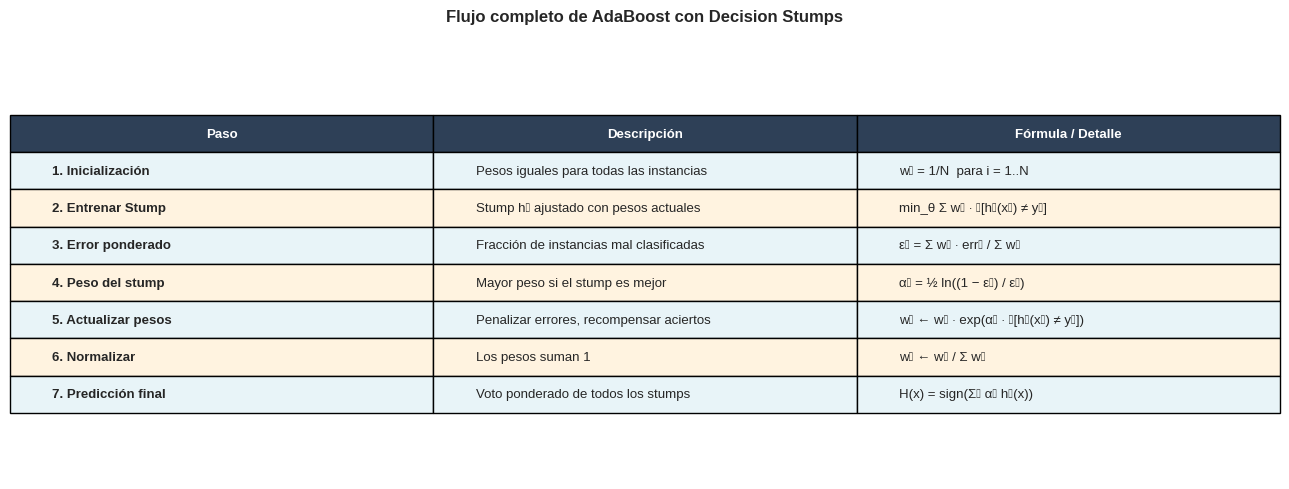


✅ CONCLUSIONES:
   • El stump solo es un predictor muy limitado (fronteras lineales, 1 variable).
   • Su fortaleza es ser un aprendiz débil controlable y rápido de entrenar.
   • AdaBoost convierte muchos stumps débiles en un ensemble fuerte.
   • Cada stump se enfoca en los errores del conjunto anterior (boosting).
   • La fórmula αₜ garantiza que stumps más precisos tengan más voz.


In [21]:
# ─── Resumen: el ciclo de vida de un stump en AdaBoost ────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.axis('off')

resumen = [
    ['Paso', 'Descripción', 'Fórmula / Detalle'],
    ['1. Inicialización',  'Pesos iguales para todas las instancias',
     'wᵢ = 1/N  para i = 1..N'],
    ['2. Entrenar Stump',  'Stump hₜ ajustado con pesos actuales',
     'min_θ Σ wᵢ · 𝟙[hₜ(xᵢ) ≠ yᵢ]'],
    ['3. Error ponderado', 'Fracción de instancias mal clasificadas',
     'εₜ = Σ wᵢ · errᵢ / Σ wᵢ'],
    ['4. Peso del stump',  'Mayor peso si el stump es mejor',
     'αₜ = ½ ln((1 − εₜ) / εₜ)'],
    ['5. Actualizar pesos','Penalizar errores, recompensar aciertos',
     'wᵢ ← wᵢ · exp(αₜ · 𝟙[hₜ(xᵢ) ≠ yᵢ])'],
    ['6. Normalizar',      'Los pesos suman 1',
     'wᵢ ← wᵢ / Σ wⱼ'],
    ['7. Predicción final','Voto ponderado de todos los stumps',
     'H(x) = sign(Σₜ αₜ hₜ(x))'],
]

tabla = ax.table(
    cellText=resumen[1:], colLabels=resumen[0],
    loc='center', cellLoc='left'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9.5)
tabla.scale(1, 2.0)

for j in range(3):
    tabla[(0, j)].set_facecolor('#2E4057')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')
colores_filas = ['#E8F4F8', '#FFF3E0', '#E8F4F8', '#FFF3E0',
                 '#E8F4F8', '#FFF3E0', '#E8F4F8']
for i, c in enumerate(colores_filas, start=1):
    for j in range(3):
        tabla[(i, j)].set_facecolor(c)
    tabla[(i, 0)].set_text_props(fontweight='bold')

ax.set_title('Flujo completo de AdaBoost con Decision Stumps',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('stump_resumen_adaboost.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n✅ CONCLUSIONES:')
print('   • El stump solo es un predictor muy limitado (fronteras lineales, 1 variable).')
print('   • Su fortaleza es ser un aprendiz débil controlable y rápido de entrenar.')
print('   • AdaBoost convierte muchos stumps débiles en un ensemble fuerte.')
print('   • Cada stump se enfoca en los errores del conjunto anterior (boosting).')
print('   • La fórmula αₜ garantiza que stumps más precisos tengan más voz.')